<center>

# **Linear Regression: From First Principles to Regularized Models**

*Deriving OLS, Gradient Descent, and Ridge/Lasso Regression with a from-scratch NumPy implementation, validated against scikit-learn on the UCI Energy Efficiency dataset*

<br>
</center>

## **Table of Contents**

1. [Introduction](#Introduction) — Motivation, historical context, and real-world applications
2. [Mathematical Foundation](#Mathematical-Foundation) — OLS cost function, Normal Equation, Gradient Descent
   - [Cost Function](#Cost-Function)
   - [Normal Equation](#Normal-Equation)
   - [Gradient Descent](#Gradient-Descent)
   - [Polynomial Regression](#Polynomial-Regression)
3. [Regularization](#Regularization) — Ridge (L2), Lasso (L1), Elastic Net, Bias-Variance Tradeoff
4. [Evaluation Metrics](#Evaluation-Metrics) — MSE, RMSE, MAE, R², Adjusted R²
5. [Data](#Data) — UCI Energy Efficiency dataset: loading, EDA, preprocessing
6. [From-Scratch Implementation](#From-Scratch-Implementation) — NumPy-based Normal Equation, Batch/SGD, Ridge, Lasso
7. [Scikit-Learn Implementation](#Scikit-Learn-Implementation) — Library baselines for comparison
8. [Experiments & Results](#Experiments-&-Results) — Training, evaluation, comparison tables
9. [Analysis & Conclusion](#Analysis-&-Conclusion) — Key observations, limitations, takeaways, and references

## **Introduction**

**Linear regression** is the cornerstone of statistical learning and the starting point for virtually every machine learning curriculum. Despite its simplicity, it introduces the fundamental concepts like cost functions, optimization, regularization, and the bias-variance tradeoff, that underpin all of modern machine learning.

### **What Is the Linear Model?**

At its core, the linear model assumes that the output $y$ is a **weighted sum** of the input features $x_1, x_2, \ldots, x_n$, plus a constant bias term. In plain language, the model says: "each feature contributes independently and proportionally to the prediction, and I can capture the overall relationship by finding the right set of weights." This is a remarkably powerful assumption for several reasons. First, linearity makes the model **analytically tractable**, meaning we can derive exact solutions, compute confidence intervals, and prove optimality guarantees that are simply unavailable for more complex models. Second, the linear model is **surprisingly expressive** in practice: by engineering the right features (polynomials, interactions, basis expansions), a "linear" model can capture highly nonlinear patterns while retaining all the mathematical conveniences of linearity in the parameters. Third, the linear model provides **unmatched transparency**. Every coefficient tells you exactly how much, and in which direction, a one-unit change in a feature affects the prediction, holding all else constant. This makes linear regression indispensable in domains like medicine, economics, and public policy, where understanding *why* a model makes a prediction matters as much as the prediction itself. Finally, the linear model serves as the **building block** for virtually every advanced technique in machine learning. Logistic regression wraps a linear model in a sigmoid; a neural network is a composition of linear transformations with nonlinear activations; support vector machines seek an optimal linear separator in a transformed space. Understanding the linear model deeply means understanding the foundation on which the entire field stands.

### **Historical Context**

The method of least squares was independently discovered by **Adrien-Marie Legendre** (1805) and **Carl Friedrich Gauss** (1809), who used it to predict the orbit of the asteroid Ceres from noisy astronomical observations. Gauss further proved that least squares is *optimal* among linear unbiased estimators when errors are normally distributed, a result later formalized as the **Gauss-Markov theorem**.

### **Why Study Linear Regression in Depth?**

Linear regression deserves deep study because it is the **foundation** upon which logistic regression, neural networks, and even deep RL critics are built, each a generalization of the linear model. Unlike many modern methods, it offers remarkable **interpretability**, where every coefficient carries a direct causal interpretation under correct specification. It is also one of the few models with a **closed-form solution**: the Normal Equation yields an exact answer with no iterative optimization. Yet when we *do* optimize iteratively, gradient descent on the linear model introduces the very same algorithm later used to train billion-parameter transformers, making it a natural **gateway to optimization**. Finally, Ridge and Lasso regression illustrate the **bias-variance tradeoff** with mathematical precision, providing the theoretical grounding for regularization techniques that recur throughout machine learning.

### **Problem: Building Energy Efficiency**

We apply linear regression to the **UCI Energy Efficiency dataset** (Tsanas & Xifara, 2012), which contains 768 simulated buildings described by 8 architectural features. The goal is to predict **heating load** (kWh/m²) from building geometry, a clean regression task at the perfect scale for demonstrating these techniques.

## **Mathematical Foundation**

### **The Linear Model**

Given a dataset of $m$ training examples $\{(\mathbf{x}^{(i)}, y^{(i)})\}_{i=1}^{m}$ where $\mathbf{x}^{(i)} \in \mathbb{R}^n$ and $y^{(i)} \in \mathbb{R}$, the linear model assumes:

$$h_\theta(\mathbf{x}) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n = \boldsymbol{\theta}^\top \mathbf{x}$$

where $\boldsymbol{\theta} = [\theta_0, \theta_1, \ldots, \theta_n]^\top \in \mathbb{R}^{n+1}$ are the model parameters (with $x_0 = 1$ as the bias/intercept term).

In matrix notation, for the entire training set:

$$\hat{\mathbf{y}} = \mathbf{X} \boldsymbol{\theta}$$

where $\mathbf{X} \in \mathbb{R}^{m \times (n+1)}$ is the **design matrix** (each row is a training example with a prepended 1).

### **Cost Function**

We seek parameters $\boldsymbol{\theta}$ that minimize the discrepancy between predictions and true values. The **Mean Squared Error (MSE)** cost function is:

$$J(\boldsymbol{\theta}) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(\mathbf{x}^{(i)}) - y^{(i)} \right)^2 = \frac{1}{2m} \| \mathbf{X}\boldsymbol{\theta} - \mathbf{y} \|^2$$

The factor $\frac{1}{2}$ is a convenience that cancels with the exponent during differentiation. The MSE is:

- **Convex**: any local minimum is a global minimum (the Hessian $\mathbf{X}^\top \mathbf{X} / m$ is positive semi-definite)
- **Differentiable**: everywhere, enabling gradient-based optimization
- **Statistically motivated**: it is the maximum likelihood estimator under Gaussian noise, i.e., if $y = \boldsymbol{\theta}^\top \mathbf{x} + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0, \sigma^2)$, then minimizing MSE is equivalent to maximizing the log-likelihood

**Proof (MSE = MLE under Gaussian noise):**

If $y^{(i)} | \mathbf{x}^{(i)}; \boldsymbol{\theta} \sim \mathcal{N}(\boldsymbol{\theta}^\top \mathbf{x}^{(i)}, \sigma^2)$, then the likelihood is:

$$L(\boldsymbol{\theta}) = \prod_{i=1}^{m} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(y^{(i)} - \boldsymbol{\theta}^\top \mathbf{x}^{(i)})^2}{2\sigma^2} \right)$$

Taking the log:

$$\ell(\boldsymbol{\theta}) = -\frac{m}{2}\ln(2\pi\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^{m} (y^{(i)} - \boldsymbol{\theta}^\top \mathbf{x}^{(i)})^2$$

Maximizing $\ell(\boldsymbol{\theta})$ is equivalent to minimizing $\sum (y^{(i)} - \boldsymbol{\theta}^\top \mathbf{x}^{(i)})^2$, which is precisely $2m \cdot J(\boldsymbol{\theta})$. $\blacksquare$

*Conceptual illustration: the MSE cost function forms a convex bowl in parameter space. Every path downhill leads to the same unique global minimum, which is what makes least-squares optimization so reliable.*

![MSE Cost Surface](illustrations/fig1_mse_cost_surface.png)

### **Normal Equation**

Since $J(\boldsymbol{\theta})$ is convex, we can find the global minimum by setting the gradient to zero:

$$\nabla_\theta J(\boldsymbol{\theta}) = \frac{1}{m} \mathbf{X}^\top (\mathbf{X}\boldsymbol{\theta} - \mathbf{y}) = \mathbf{0}$$

**Derivation step by step:**

Expand $J$ in matrix form:

$$J(\boldsymbol{\theta}) = \frac{1}{2m} (\mathbf{X}\boldsymbol{\theta} - \mathbf{y})^\top (\mathbf{X}\boldsymbol{\theta} - \mathbf{y})$$

$$= \frac{1}{2m} \left( \boldsymbol{\theta}^\top \mathbf{X}^\top \mathbf{X} \boldsymbol{\theta} - 2\boldsymbol{\theta}^\top \mathbf{X}^\top \mathbf{y} + \mathbf{y}^\top \mathbf{y} \right)$$

Using matrix calculus identities $\frac{\partial}{\partial \boldsymbol{\theta}} \boldsymbol{\theta}^\top \mathbf{A} \boldsymbol{\theta} = 2\mathbf{A}\boldsymbol{\theta}$ (for symmetric $\mathbf{A}$) and $\frac{\partial}{\partial \boldsymbol{\theta}} \boldsymbol{\theta}^\top \mathbf{b} = \mathbf{b}$:

$$\nabla_\theta J = \frac{1}{2m} \left( 2\mathbf{X}^\top \mathbf{X} \boldsymbol{\theta} - 2\mathbf{X}^\top \mathbf{y} \right) = \frac{1}{m} \left( \mathbf{X}^\top \mathbf{X} \boldsymbol{\theta} - \mathbf{X}^\top \mathbf{y} \right)$$

Setting $\nabla_\theta J = \mathbf{0}$:

$$\mathbf{X}^\top \mathbf{X} \boldsymbol{\theta} = \mathbf{X}^\top \mathbf{y}$$

If $\mathbf{X}^\top \mathbf{X}$ is invertible (i.e., all its eigenvalues are nonzero, which holds when no feature is a perfect linear combination of the others):

$$\boxed{\boldsymbol{\theta}^* = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}}$$

This is the **Normal Equation** — a closed-form solution requiring no iteration.

**Computational complexity**: $O(n^2 m + n^3)$. To see where each term comes from, trace through the operations in $(\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$:

1. **$\mathbf{X}^\top \mathbf{X}$**: multiplying an $n \times m$ matrix by an $m \times n$ matrix produces an $n \times n$ result. Each of the $n^2$ entries is a dot product of length $m$, so the total cost is $O(n^2 m)$. This is the **data pass**, and it dominates when the number of samples $m$ is much larger than $n$.
2. **$\mathbf{X}^\top \mathbf{y}$**: a matrix-vector product costing $O(nm)$, which is absorbed by the $n^2 m$ term above.
3. **$(\mathbf{X}^\top \mathbf{X})^{-1}$**: inverting (or factoring) the $n \times n$ matrix via Gaussian elimination costs $O(n^3)$. This is the **inversion bottleneck**, and it dominates when $n$ is large.
4. **$(\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$**: a final matrix-vector multiply costing $O(n^2)$, negligible compared to the previous steps.

Combining these: the total cost is $O(n^2 m + n^3)$. For our dataset ($m = 768$, $n = 8$), this amounts to roughly $768 \times 64 + 512 \approx 50{,}000$ floating-point operations, which is trivial. But at $n = 10{,}000$ the inversion term alone reaches $10^{12}$ operations, making the Normal Equation impractical; gradient descent becomes the only viable option.

> **Note**: When $\mathbf{X}^\top \mathbf{X}$ is singular (collinear features), the pseudo-inverse $(\mathbf{X}^\top \mathbf{X})^+ \mathbf{X}^\top \mathbf{y}$ provides a minimum-norm solution. Regularization (Ridge/Lasso) also resolves this by ensuring invertibility.

*Conceptual illustration: the Normal Equation finds the point in the column space of X that is closest to y. The residual vector is orthogonal to the column space, which is precisely the condition $\mathbf{X}^\top(\mathbf{y} - \mathbf{X}\boldsymbol{\theta}^*) = \mathbf{0}$.*

![Normal Equation as Projection](illustrations/fig2_normal_equation_projection.png)

### **Gradient Descent**

When the Normal Equation is too expensive (large $n$), we use **gradient descent**, an iterative algorithm that moves $\boldsymbol{\theta}$ in the direction of steepest descent of $J$:

$$\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \alpha \nabla_\theta J(\boldsymbol{\theta})$$

where $\alpha > 0$ is the **learning rate**.

**Why the negative gradient?** Consider a first-order Taylor expansion of the cost around the current $\boldsymbol{\theta}$:

$$J(\boldsymbol{\theta} + \boldsymbol{\delta}) \approx J(\boldsymbol{\theta}) + \nabla_\theta J(\boldsymbol{\theta})^\top \boldsymbol{\delta}$$

Choosing $\boldsymbol{\delta} = -\alpha \nabla_\theta J(\boldsymbol{\theta})$ gives:

$$J(\boldsymbol{\theta} - \alpha \nabla_\theta J) \approx J(\boldsymbol{\theta}) - \alpha \|\nabla_\theta J\|^2$$

Since $\|\nabla_\theta J\|^2 \geq 0$, the cost is guaranteed to decrease (for small enough $\alpha$). By the Cauchy–Schwarz inequality, the negative gradient is also the direction that maximizes this decrease per unit step, making it the direction of *steepest descent*.

#### **Batch Gradient Descent**

Compute the gradient using *all* $m$ training examples:

$$\nabla_\theta J(\boldsymbol{\theta}) = \frac{1}{m} \mathbf{X}^\top (\mathbf{X}\boldsymbol{\theta} - \mathbf{y})$$

For each parameter $\theta_j$:

$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(\mathbf{x}^{(i)}) - y^{(i)} \right) x_j^{(i)}$$

To see how these two forms are equivalent, consider the $j$-th component of the matrix expression $\mathbf{X}^\top(\mathbf{X}\boldsymbol{\theta} - \mathbf{y})$. The $j$-th row of $\mathbf{X}^\top$ contains the values $x_j^{(1)}, x_j^{(2)}, \ldots, x_j^{(m)}$, and $\mathbf{X}\boldsymbol{\theta} - \mathbf{y}$ is the vector of residuals $(\hat{y}^{(i)} - y^{(i)})$. Their dot product is:

$$\left[\mathbf{X}^\top(\mathbf{X}\boldsymbol{\theta} - \mathbf{y})\right]_j = \sum_{i=1}^{m} x_j^{(i)}\left(\hat{y}^{(i)} - y^{(i)}\right) = \sum_{i=1}^{m} \left(h_\theta(\mathbf{x}^{(i)}) - y^{(i)}\right) x_j^{(i)}$$

Dividing by $m$ recovers the per-parameter partial derivative $\frac{\partial J}{\partial \theta_j}$.

- **Convergence**: guaranteed to reach the global minimum for convex $J$ if $\alpha$ is small enough
- **Cost per iteration**: $O(mn)$ — one full pass over the data

#### **Stochastic Gradient Descent (SGD)**

Update $\boldsymbol{\theta}$ after *each* training example $(\mathbf{x}^{(i)}, y^{(i)})$:

$$\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \alpha \left( h_\theta(\mathbf{x}^{(i)}) - y^{(i)} \right) \mathbf{x}^{(i)}$$

- **Cost per iteration**: $O(n)$ — one example
- **Convergence**: noisy oscillations around the minimum; requires decaying learning rate $\alpha_t \to 0$ with $\sum \alpha_t = \infty$ and $\sum \alpha_t^2 < \infty$ (Robbins–Monro conditions)

#### **Mini-Batch Gradient Descent**

A compromise: compute the gradient over a random subset (mini-batch) of size $B$:

$$\nabla_\theta J \approx \frac{1}{B} \sum_{i \in \mathcal{B}} \left( h_\theta(\mathbf{x}^{(i)}) - y^{(i)} \right) \mathbf{x}^{(i)}$$

| Variant | Cost/Iteration | Convergence | Parallelism |
|---------|---------------|-------------|-------------|
| Batch GD | $O(mn)$ | Smooth, deterministic | Low |
| SGD | $O(n)$ | Noisy, needs $\alpha$ decay | None |
| Mini-Batch | $O(Bn)$ | Best of both worlds | High (vectorized) |

#### **Convergence Analysis**

For batch GD on the MSE cost, the Hessian is constant:

$$\nabla^2 J = \frac{1}{m}\mathbf{X}^\top\mathbf{X}$$

A twice-differentiable function is convex if and only if its Hessian is positive semi-definite everywhere. We already know $\mathbf{X}^\top\mathbf{X}$ is PSD (since $\mathbf{v}^\top\mathbf{X}^\top\mathbf{X}\mathbf{v} = \|\mathbf{X}\mathbf{v}\|^2 \geq 0$ for any $\mathbf{v}$), and scaling by $1/m > 0$ preserves this property, so $J$ is convex. Crucially, this Hessian does not depend on $\boldsymbol{\theta}$, which makes $J$ a quadratic function: the simplest possible convex landscape.

**What the eigenvalues tell us.** The eigenvalues of the Hessian control how the cost surface *curves* in each direction. If you picture the cost surface as a bowl, the largest eigenvalue $\lambda_{\max}$ measures the steepest wall, while the smallest eigenvalue $\lambda_{\min}$ measures the shallowest wall. More precisely:

- $L = \lambda_{\max}(\mathbf{X}^\top\mathbf{X}/m)$ is the **smoothness constant**. It bounds how fast the gradient can change: $\|\nabla J(\boldsymbol{\theta}') - \nabla J(\boldsymbol{\theta})\| \leq L\|\boldsymbol{\theta}' - \boldsymbol{\theta}\|$. A large $L$ means the gradient can swing rapidly, requiring a smaller learning rate for stability.
- $\mu = \lambda_{\min}(\mathbf{X}^\top\mathbf{X}/m)$ is the **strong-convexity constant** (assuming full column rank, so $\mu > 0$). It guarantees the cost always curves at least this much, ruling out flat valleys where gradient descent would stall.

**Deriving the quadratic upper bound.** For any $L$-smooth function, the gradient's rate of change is bounded by $L$, which yields a quadratic upper bound on $J$:

$$J(\boldsymbol{\theta}') \leq \underbrace{J(\boldsymbol{\theta})}_{\text{current cost}} + \underbrace{\nabla J(\boldsymbol{\theta})^\top(\boldsymbol{\theta}' - \boldsymbol{\theta})}_{\text{linear (tangent) change}} + \underbrace{\frac{L}{2}\|\boldsymbol{\theta}' - \boldsymbol{\theta}\|^2}_{\text{curvature safety margin}}$$

The first two terms form the tangent-plane (first-order Taylor) approximation; the third adds a worst-case correction because the true function curves, so the linear approximation eventually underestimates the cost.

For MSE specifically, we can verify this directly. The exact second-order expansion is:

$$J(\boldsymbol{\theta}') = J(\boldsymbol{\theta}) + \nabla J(\boldsymbol{\theta})^\top(\boldsymbol{\theta}' - \boldsymbol{\theta}) + \frac{1}{2}(\boldsymbol{\theta}' - \boldsymbol{\theta})^\top \frac{\mathbf{X}^\top\mathbf{X}}{m}(\boldsymbol{\theta}' - \boldsymbol{\theta})$$

The quadratic term satisfies $(\boldsymbol{\theta}' - \boldsymbol{\theta})^\top \frac{\mathbf{X}^\top\mathbf{X}}{m}(\boldsymbol{\theta}' - \boldsymbol{\theta}) \leq \lambda_{\max}\|\boldsymbol{\theta}' - \boldsymbol{\theta}\|^2 = L\|\boldsymbol{\theta}' - \boldsymbol{\theta}\|^2$, because the largest a quadratic form $\mathbf{v}^\top\mathbf{A}\mathbf{v}$ can be (for fixed $\|\mathbf{v}\|$) is $\lambda_{\max}(\mathbf{A})\|\mathbf{v}\|^2$, achieved when $\mathbf{v}$ aligns with the top eigenvector. Dividing by 2 recovers the bound.

**From upper bound to convergence rate.** Substituting the gradient-descent step $\boldsymbol{\theta}' = \boldsymbol{\theta} - \alpha\nabla J$:

$$J(\boldsymbol{\theta}') \leq J(\boldsymbol{\theta}) - \alpha\|\nabla J\|^2 + \frac{L\alpha^2}{2}\|\nabla J\|^2 = J(\boldsymbol{\theta}) - \alpha\!\left(1 - \frac{L\alpha}{2}\right)\|\nabla J\|^2$$

The right-hand side decreases whenever $\alpha < 2/L$. The tightest bound occurs at $\alpha = 1/L$, giving:

$$J(\boldsymbol{\theta}') \leq J(\boldsymbol{\theta}) - \frac{1}{2L}\|\nabla J\|^2$$

Combining this with **$\mu$-strong convexity** ($\|\nabla J\|^2 \geq 2\mu(J - J^*)$) yields the per-step contraction:

$$J(\boldsymbol{\theta}^{(t+1)}) - J^* \leq \left(1 - \frac{\mu}{L}\right)\bigl(J(\boldsymbol{\theta}^{(t)}) - J^*\bigr)$$

Unrolling over $t$ steps:

$$J(\boldsymbol{\theta}^{(t)}) - J^* \leq \left(1 - \kappa^{-1}\right)^t \bigl(J(\boldsymbol{\theta}^{(0)}) - J^*\bigr)$$

where $\kappa = L/\mu = \lambda_{\max}/\lambda_{\min}$ is the **condition number** of $\mathbf{X}^\top\mathbf{X}$. Convergence is **linear** with rate $1 - \kappa^{-1}$, so poorly conditioned problems (large $\kappa$) converge slowly. **Feature scaling** brings eigenvalues closer together, reducing $\kappa$ and accelerating convergence.

### **Polynomial Regression**

The linear model can capture **nonlinear relationships** by augmenting the feature vector with polynomial terms:

$$\phi(\mathbf{x}) = [1, x_1, x_2, \ldots, x_n, x_1^2, x_1 x_2, \ldots, x_n^d]$$

The model $h_\theta(\mathbf{x}) = \boldsymbol{\theta}^\top \phi(\mathbf{x})$ is still **linear in $\boldsymbol{\theta}$** (so the Normal Equation and GD still apply) but **nonlinear in $\mathbf{x}$**.

The risk: as polynomial degree $d$ increases, the model becomes more flexible but increasingly prone to **overfitting**. Meaning it memorizes noise in the training data rather than capturing the true relationship. We will visualize this tradeoff explicitly.

## **Regularization**

Regularization adds a **penalty term** to the cost function to constrain the model complexity, preventing overfitting by discouraging large parameter values.

### **Ridge Regression (L2 Regularization)**

$$J_{\text{Ridge}}(\boldsymbol{\theta}) = \frac{1}{2m} \| \mathbf{X}\boldsymbol{\theta} - \mathbf{y} \|^2 + \lambda \| \boldsymbol{\theta}_{1:} \|_2^2$$

where $\boldsymbol{\theta}_{1:} = [\theta_1, \ldots, \theta_n]^\top$ (we do not regularize the intercept $\theta_0$) and $\lambda > 0$ controls the regularization strength.

**Derivation from constrained optimization:**

Ridge is equivalent to solving:

$$\min_{\boldsymbol{\theta}} \frac{1}{2m} \| \mathbf{X}\boldsymbol{\theta} - \mathbf{y} \|^2 \quad \text{subject to} \quad \| \boldsymbol{\theta}_{1:} \|_2^2 \leq t$$

By the **method of Lagrange multipliers**, the constraint is absorbed into the objective with multiplier $\lambda$ (which corresponds to $t$ via a monotone relationship).

**Closed-form solution:**

Setting $\nabla_\theta J_{\text{Ridge}} = \mathbf{0}$:

$$\frac{1}{m} \mathbf{X}^\top (\mathbf{X}\boldsymbol{\theta} - \mathbf{y}) + 2\lambda \boldsymbol{\theta} = \mathbf{0}$$

$$\boldsymbol{\theta}^*_{\text{Ridge}} = (\mathbf{X}^\top \mathbf{X} + 2m\lambda \mathbf{I})^{-1} \mathbf{X}^\top \mathbf{y}$$

The term $2m\lambda \mathbf{I}$ ensures the matrix is always invertible, even when $\mathbf{X}^\top \mathbf{X}$ is singular. This is why Ridge regression is also called **Tikhonov regularization**.

**Gradient for GD:**

$$\nabla_\theta J_{\text{Ridge}} = \frac{1}{m} \mathbf{X}^\top (\mathbf{X}\boldsymbol{\theta} - \mathbf{y}) + 2\lambda \boldsymbol{\theta}$$

### **Lasso Regression (L1 Regularization)**

$$J_{\text{Lasso}}(\boldsymbol{\theta}) = \frac{1}{2m} \| \mathbf{X}\boldsymbol{\theta} - \mathbf{y} \|^2 + \lambda \| \boldsymbol{\theta}_{1:} \|_1$$

The L1 penalty $\| \boldsymbol{\theta}_{1:} \|_1 = \sum_{j=1}^{n} |\theta_j|$ produces **sparse solutions** — it drives some coefficients exactly to zero, performing automatic **feature selection**.

**Why L1 induces sparsity (geometric intuition):**

The L1 constraint set $\{\boldsymbol{\theta} : \| \boldsymbol{\theta} \|_1 \leq t\}$ is a **diamond** (hypercube rotated 45°) in parameter space. The elliptical MSE contours are more likely to intersect the diamond at a *vertex* (where some coordinates are zero) than at an edge. In contrast, the L2 constraint set is a **sphere**, and the contours typically intersect at a smooth point where no coordinate is exactly zero.

**Optimization:** Lasso has no closed-form solution because the L1 norm is **not differentiable** at zero. We use **coordinate descent** (or subgradient methods):

For each $\theta_j$, the subgradient update is:

$$\theta_j \leftarrow \mathcal{S}_{\lambda\alpha}\left(\theta_j - \alpha \frac{\partial}{\partial \theta_j} \frac{1}{2m}\|\mathbf{X}\boldsymbol{\theta} - \mathbf{y}\|^2 \right)$$

where $\mathcal{S}_\kappa(z) = \text{sign}(z) \max(|z| - \kappa, 0)$ is the **soft-thresholding (proximal) operator**.

### **Elastic Net**

Combines L1 and L2 penalties:

$$J_{\text{ElasticNet}}(\boldsymbol{\theta}) = \frac{1}{2m} \| \mathbf{X}\boldsymbol{\theta} - \mathbf{y} \|^2 + \lambda_1 \| \boldsymbol{\theta}_{1:} \|_1 + \lambda_2 \| \boldsymbol{\theta}_{1:} \|_2^2$$

This addresses Lasso's instability when features are correlated (it arbitrarily selects one from a group).

### **Bias-Variance Tradeoff**

The expected prediction error for any estimator $\hat{f}$ decomposes as:

$$\mathbb{E}\left[(y - \hat{f}(\mathbf{x}))^2\right] = \underbrace{\left(\mathbb{E}[\hat{f}(\mathbf{x})] - f(\mathbf{x})\right)^2}_{\text{Bias}^2} + \underbrace{\mathbb{E}\left[(\hat{f}(\mathbf{x}) - \mathbb{E}[\hat{f}(\mathbf{x})])^2\right]}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{Irreducible noise}}$$

| | Low Regularization ($\lambda \to 0$) | High Regularization ($\lambda \to \infty$) |
|---|---|---|
| **Bias** | Low (model is flexible) | High (model is constrained) |
| **Variance** | High (model is sensitive to data) | Low (model is stable) |
| **Total Error** | Dominated by variance | Dominated by bias |

The optimal $\lambda$ minimizes the total error — a tradeoff we will visualize empirically.

*Conceptual illustration: L2 regularization constrains weights to a sphere, where MSE contours intersect at a smooth point (no coefficients are exactly zero). L1 constrains weights to a diamond with sharp vertices, so the MSE contours are likely to hit a corner where some coefficients are driven to exactly zero, producing sparse solutions.*

![L1 vs L2 Constraint Geometry](illustrations/fig3_l1_vs_l2_geometry.png)

*Conceptual illustration: the bias-variance tradeoff. Simple models (high regularization) underfit with high bias; complex models (low regularization) overfit with high variance. The optimal complexity minimizes total prediction error.*

![Bias-Variance Tradeoff](illustrations/fig4_bias_variance_tradeoff.png?v=2)

## **Evaluation Metrics**

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MSE** | $\frac{1}{m}\sum(y_i - \hat{y}_i)^2$ | Average squared error; penalizes large errors heavily |
| **RMSE** | $\sqrt{\text{MSE}}$ | Same units as $y$; most common regression metric |
| **MAE** | $\frac{1}{m}\sum\lvert y_i - \hat{y}_i\rvert$ | Average absolute error; robust to outliers |
| **R²** | $1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Proportion of variance explained; $R^2 = 1$ is perfect |
| **Adjusted R²** | $1 - \frac{(1-R^2)(m-1)}{m-n-1}$ | Penalizes adding features; prevents overfitting illusion |

**R² derivation:**

Define the **Total Sum of Squares** $SS_{\text{tot}} = \sum(y_i - \bar{y})^2$ (total variance in data) and the **Residual Sum of Squares** $SS_{\text{res}} = \sum(y_i - \hat{y}_i)^2$ (variance unexplained by the model). Then:

$$R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}$$

- $R^2 = 1$: model explains all variance (perfect fit)
- $R^2 = 0$: model is no better than predicting $\bar{y}$
- $R^2 < 0$: model is *worse* than the mean predictor

## **Data**

### **UCI Energy Efficiency Dataset**

The dataset was created by Tsanas & Xifara (2012) using **Ecotect** energy analysis simulations of 12 different building shapes, each with systematic variations in glazing area, glazing distribution, and orientation. The simulation produced 768 samples, each described by 8 architectural features and two energy targets: **heating load** and **cooling load** (both in kWh/m²). We focus exclusively on predicting heating load.

Several features are strongly correlated with one another (compactness, surface area, roof area, and height are geometrically linked), which makes this dataset a natural testbed for regularization methods like Ridge and Lasso that handle multicollinearity gracefully.

### **Why This Problem?**

Building energy efficiency is a critical concern in sustainable design: heating and cooling account for roughly 40% of total energy consumption in residential buildings across Europe and North America. Architects and engineers need fast, interpretable models that can estimate a building's energy demand *before* construction, based solely on geometric design parameters. This is precisely the setting where linear regression excels. The features are continuous or low-cardinality ordinal variables with clear physical meaning, the target is a continuous quantity with a plausible linear relationship to building geometry, and the dataset is small enough that a closed-form solution is computationally trivial. Moreover, interpretability is paramount here: stakeholders want to know *which* design decisions (compactness, glazing area, height) have the greatest impact on heating costs, and by how much, not just a black-box prediction. Linear regression provides exactly that through its coefficients.

### **Feature Descriptions**

| Feature | Description | Range |
|---------|-------------|-------|
| $x_1$ — Relative Compactness | Surface area to volume ratio | 0.62 – 0.98 |
| $x_2$ — Surface Area | Total exterior surface (m²) | 514 – 808 |
| $x_3$ — Wall Area | Exterior wall surface (m²) | 245 – 416 |
| $x_4$ — Roof Area | Roof surface (m²) | 110 – 220 |
| $x_5$ — Overall Height | Building height (m) | 3.5 – 7.0 |
| $x_6$ — Orientation | Cardinal direction (2–5) | 2 – 5 |
| $x_7$ — Glazing Area | Window-to-wall ratio | 0 – 0.40 |
| $x_8$ — Glazing Distribution | Window placement (0–5) | 0 – 5 |
| $y$ — **Heating Load** | Energy for heating (kWh/m²) | 6.01 – 43.10 |

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
import random

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

# Reproducibility 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

### **Load & Explore**

In [22]:
# Load the UCI Energy Efficiency dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
try:
    df = pd.read_excel(url, engine="openpyxl")
except Exception:
    # Fallback: try local copy
    df = pd.read_excel("data/ENB2012_data.xlsx", engine="openpyxl")

# Column names from the dataset documentation
df.columns = [
    "Relative_Compactness", "Surface_Area", "Wall_Area", "Roof_Area",
    "Overall_Height", "Orientation", "Glazing_Area", "Glazing_Distribution",
    "Heating_Load", "Cooling_Load"
]

# Drop any rows that are entirely NaN (some versions of the file have trailing rows)
df.dropna(how="all", inplace=True)

print(f"Dataset shape: {df.shape}")
print(f"Features: {df.columns[:8].tolist()}")
print("Target: Heating_Load")
print("\nFirst 5 rows:")
df.head()

Dataset shape: (768, 10)
Features: ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Distribution']
Target: Heating_Load

First 5 rows:


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


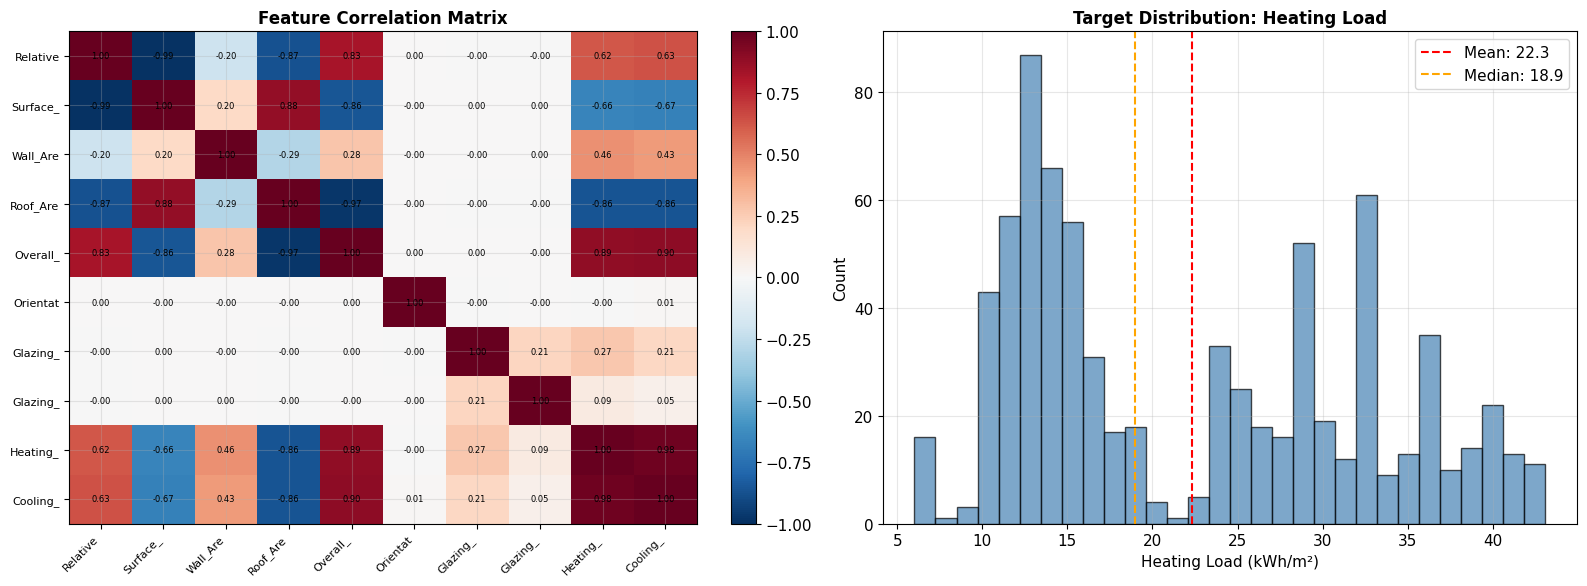

In [23]:
# Correlation heatmap 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation matrix
corr = df.corr()
im = axes[0].imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
axes[0].set_xticks(range(len(corr.columns)))
axes[0].set_yticks(range(len(corr.columns)))
axes[0].set_xticklabels([c[:8] for c in corr.columns], rotation=45, ha="right", fontsize=8)
axes[0].set_yticklabels([c[:8] for c in corr.columns], fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        axes[0].text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=6)
axes[0].set_title("Feature Correlation Matrix", fontsize=12, fontweight="bold")
fig.colorbar(im, ax=axes[0], fraction=0.046)

# Heating Load distribution
axes[1].hist(df["Heating_Load"], bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[1].axvline(df["Heating_Load"].mean(), color="red", linestyle="--", label=f"Mean: {df['Heating_Load'].mean():.1f}")
axes[1].axvline(df["Heating_Load"].median(), color="orange", linestyle="--", label=f"Median: {df['Heating_Load'].median():.1f}")
axes[1].set_xlabel("Heating Load (kWh/m²)")
axes[1].set_ylabel("Count")
axes[1].set_title("Target Distribution: Heating Load", fontsize=12, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

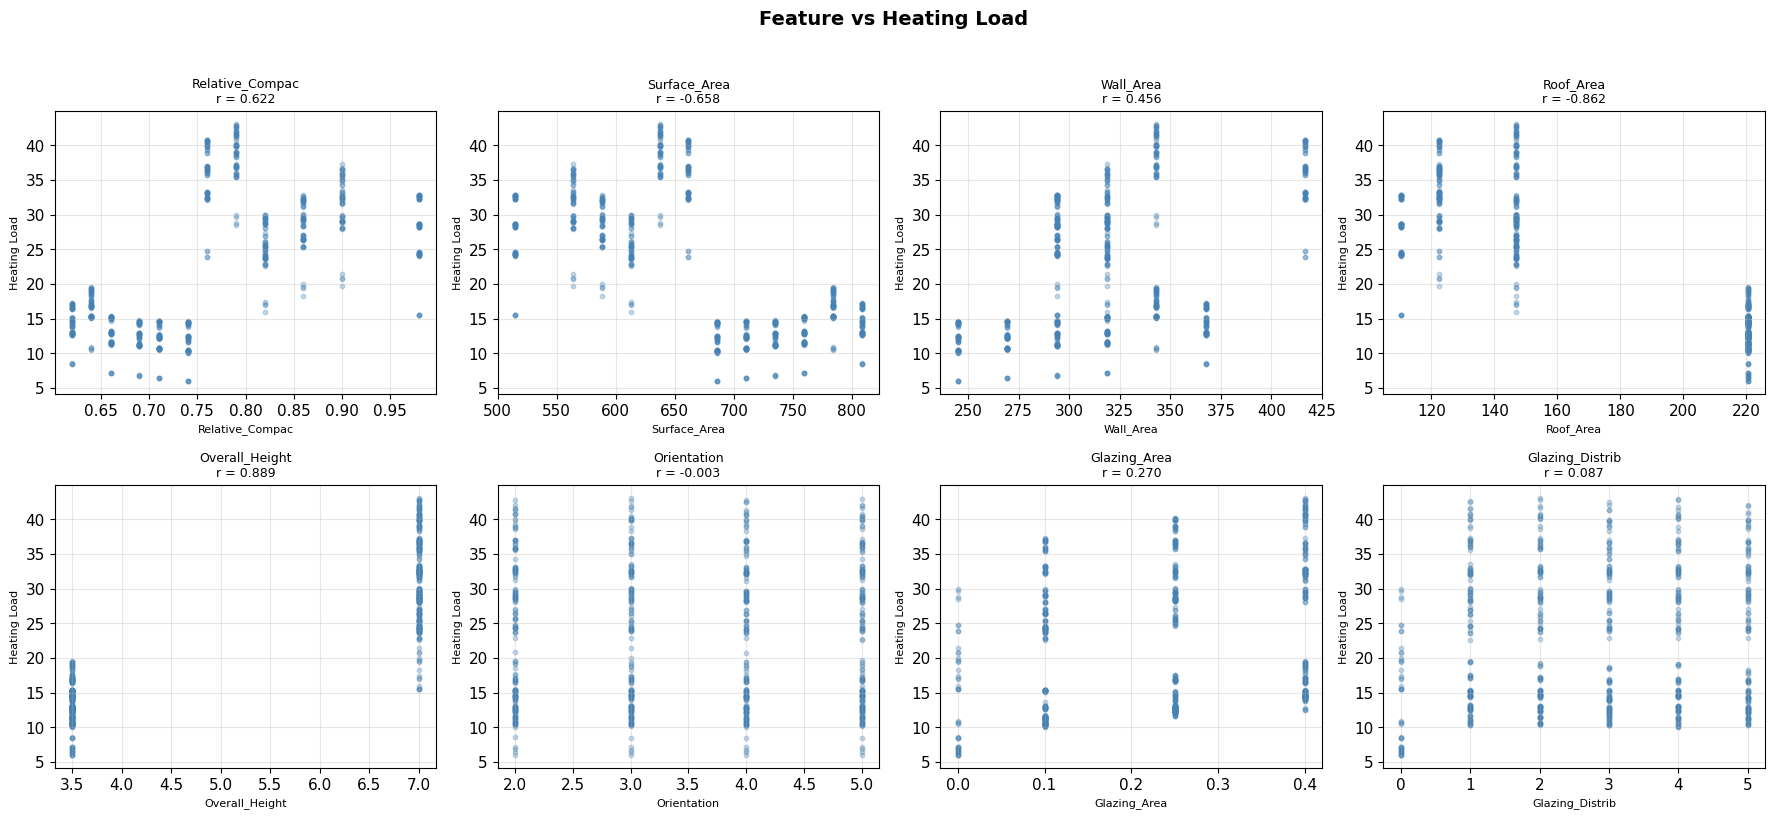

In [24]:
# Feature-target scatter plots 
features = df.columns[:8].tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].scatter(df[feat], df["Heating_Load"], alpha=0.3, s=10, color="steelblue")
    # Add correlation coefficient
    r = df[feat].corr(df["Heating_Load"])
    axes[i].set_title(f"{feat[:15]}\nr = {r:.3f}", fontsize=9)
    axes[i].set_xlabel(feat[:15], fontsize=8)
    axes[i].set_ylabel("Heating Load", fontsize=8)

plt.suptitle("Feature vs Heating Load", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### **Preprocessing**

In [25]:
# Train/test split and feature scaling 
X = df[features].values
y = df["Heating_Load"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Test set:     {X_test_scaled.shape[0]} samples")
print(f"Features:     {X_train_scaled.shape[1]}")
print(f"\nFeature means after scaling: {X_train_scaled.mean(axis=0).round(6)}")
print(f"Feature stds after scaling:  {X_train_scaled.std(axis=0).round(4)}")

Training set: 614 samples
Test set:     154 samples
Features:     8

Feature means after scaling: [-0. -0.  0. -0. -0.  0. -0.  0.]
Feature stds after scaling:  [1. 1. 1. 1. 1. 1. 1. 1.]


## **From-Scratch Implementation**

We now implement all regression methods using only NumPy, following the mathematical derivations above.

### **Evaluation Utilities**

In [26]:
# Evaluation metrics (from scratch) 
def mse(y_true, y_pred):
    """Mean Squared Error."""
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    """Root Mean Squared Error."""
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    """Mean Absolute Error."""
    return np.mean(np.abs(y_true - y_pred))

def r_squared(y_true, y_pred):
    """Coefficient of Determination (R²)."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

def adjusted_r_squared(y_true, y_pred, n_features):
    """Adjusted R² that penalizes additional features."""
    r2 = r_squared(y_true, y_pred)
    m = len(y_true)
    return 1 - (1 - r2) * (m - 1) / (m - n_features - 1)

def evaluate(y_true, y_pred, n_features, name="Model"):
    """Compute and return all metrics as a dict."""
    metrics = {
        "MSE": mse(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
        "R²": r_squared(y_true, y_pred),
        "Adj. R²": adjusted_r_squared(y_true, y_pred, n_features),
    }
    return metrics

### **Normal Equation**

Direct implementation of $\boldsymbol{\theta}^* = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$:

In [27]:
class LinearRegressionScratch:
    """Ordinary Least Squares via the Normal Equation."""

    def __init__(self):
        self.theta = None

    def fit(self, X, y):
        m, n = X.shape
        # Prepend bias column
        X_b = np.c_[np.ones((m, 1)), X]
        # Normal Equation: θ = (X^T X)^{-1} X^T y
        self.theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        return self

    def predict(self, X):
        m = X.shape[0]
        X_b = np.c_[np.ones((m, 1)), X]
        return X_b @ self.theta

    @property
    def intercept(self):
        return self.theta[0]

    @property
    def coefficients(self):
        return self.theta[1:]


# Fit and evaluate
ols_scratch = LinearRegressionScratch().fit(X_train_scaled, y_train)
y_pred_ols = ols_scratch.predict(X_test_scaled)
metrics_ols = evaluate(y_test, y_pred_ols, X_train_scaled.shape[1], "OLS (Normal Eq.)")

print("OLS via Normal Equation")
print(f"  Intercept: {ols_scratch.intercept:.4f}")
print(f"  Coefficients: {np.round(ols_scratch.coefficients, 4)}")
for k, v in metrics_ols.items():
    print(f"  {k}: {v:.4f}")

OLS via Normal Equation
  Intercept: 22.1550
  Coefficients: [ -5.9487 -13.6134   6.4032   7.3602   7.2155  -0.0359   2.7001   0.3273]
  MSE: 9.5922
  RMSE: 3.0971
  MAE: 2.3141
  R²: 0.9080
  Adj. R²: 0.9029


### **Gradient Descent**

Implementation of batch gradient descent, mini-batch GD, and stochastic gradient descent with loss history tracking:

In [28]:
class GradientDescentRegression:
    """Linear regression via gradient descent (batch, mini-batch, or SGD)."""

    def __init__(self, lr=0.01, n_iters=1000, batch_size=None, tol=1e-7):
        self.lr = lr
        self.n_iters = n_iters
        self.batch_size = batch_size   # None = batch GD, 1 = SGD, else mini-batch
        self.tol = tol
        self.theta = None
        self.loss_history = []
        self.theta_history = []

    def _cost(self, X_b, y):
        m = len(y)
        residuals = X_b @ self.theta - y
        return (1 / (2 * m)) * np.sum(residuals ** 2)

    def fit(self, X, y):
        m, n = X.shape
        X_b = np.c_[np.ones((m, 1)), X]
        self.theta = np.zeros(n + 1)
        self.loss_history = []
        self.theta_history = [self.theta.copy()]

        bs = self.batch_size if self.batch_size else m  # batch GD if None

        for epoch in range(self.n_iters):
            # Shuffle for SGD / mini-batch
            indices = np.random.permutation(m)
            X_shuffled = X_b[indices]
            y_shuffled = y[indices]

            for start in range(0, m, bs):
                end = min(start + bs, m)
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]
                b = end - start

                # Gradient: (1/b) * X^T (Xθ - y)
                gradient = (1 / b) * X_batch.T @ (X_batch @ self.theta - y_batch)
                self.theta -= self.lr * gradient

            loss = self._cost(X_b, y)
            self.loss_history.append(loss)
            self.theta_history.append(self.theta.copy())

            # Convergence check
            if len(self.loss_history) > 1 and abs(self.loss_history[-2] - loss) < self.tol:
                break

        return self

    def predict(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return X_b @ self.theta

    @property
    def intercept(self):
        return self.theta[0]

    @property
    def coefficients(self):
        return self.theta[1:]


# Train: Batch GD, Mini-Batch GD, SGD 
gd_batch = GradientDescentRegression(lr=0.05, n_iters=500).fit(X_train_scaled, y_train)
gd_mini  = GradientDescentRegression(lr=0.01, n_iters=500, batch_size=32).fit(X_train_scaled, y_train)
gd_sgd   = GradientDescentRegression(lr=0.005, n_iters=300, batch_size=1).fit(X_train_scaled, y_train)

print("Batch GD converged in", len(gd_batch.loss_history), "epochs")
print("Mini-Batch GD converged in", len(gd_mini.loss_history), "epochs")
print("SGD converged in", len(gd_sgd.loss_history), "epochs")

Batch GD converged in 500 epochs
Mini-Batch GD converged in 500 epochs
SGD converged in 300 epochs


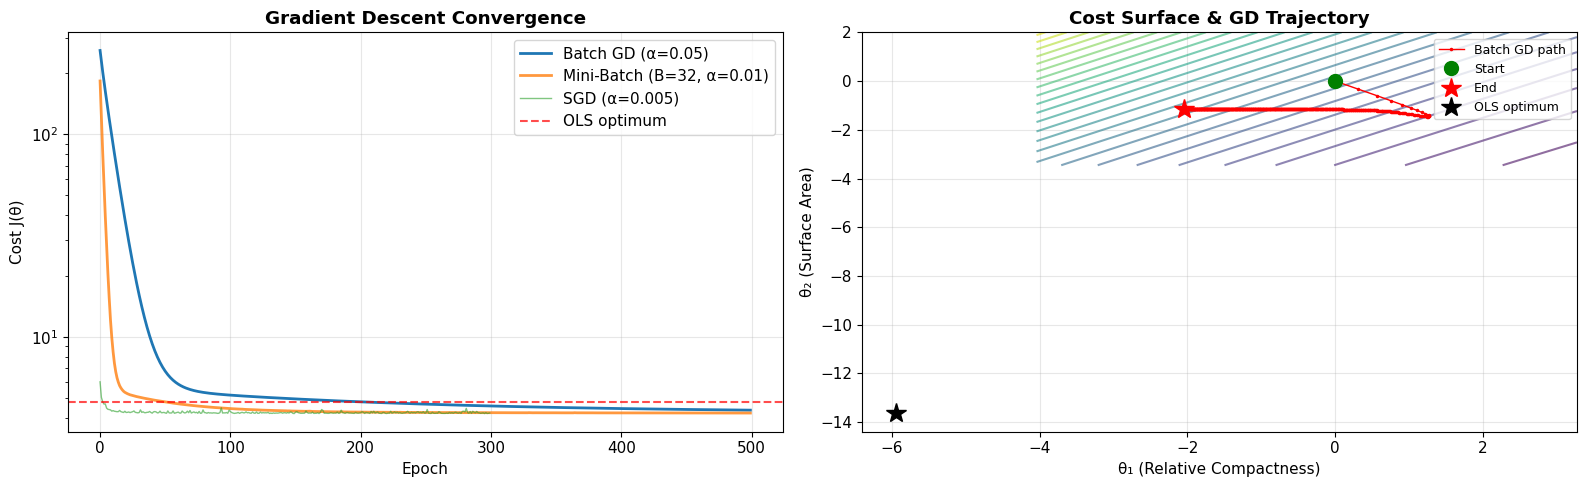

In [29]:
# Gradient Descent: Convergence Visualization 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss curves
axes[0].plot(gd_batch.loss_history, label="Batch GD (α=0.05)", linewidth=2)
axes[0].plot(gd_mini.loss_history, label="Mini-Batch (B=32, α=0.01)", linewidth=2, alpha=0.8)
axes[0].plot(gd_sgd.loss_history, label="SGD (α=0.005)", linewidth=1, alpha=0.6)
axes[0].axhline(y=metrics_ols["MSE"] / 2, color="red", linestyle="--", label="OLS optimum", alpha=0.7)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cost J(θ)")
axes[0].set_title("Gradient Descent Convergence", fontweight="bold")
axes[0].legend()
axes[0].set_yscale("log")

# Gradient descent trajectory on 2D cost surface (first two parameters)
# Use only θ_1 and θ_2 for visualization, fixing others at optimal
theta_path = np.array(gd_batch.theta_history)
t1_range = np.linspace(theta_path[:, 1].min() - 2, theta_path[:, 1].max() + 2, 100)
t2_range = np.linspace(theta_path[:, 2].min() - 2, theta_path[:, 2].max() + 2, 100)
T1, T2 = np.meshgrid(t1_range, t2_range)

# Cost surface: fix all params except θ_1, θ_2 at their OLS values
X_b_train = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
theta_fixed = ols_scratch.theta.copy()
Z = np.zeros_like(T1)
for i in range(T1.shape[0]):
    for j in range(T1.shape[1]):
        theta_tmp = theta_fixed.copy()
        theta_tmp[1] = T1[i, j]
        theta_tmp[2] = T2[i, j]
        residuals = X_b_train @ theta_tmp - y_train
        Z[i, j] = np.mean(residuals ** 2) / 2

axes[1].contour(T1, T2, Z, levels=30, cmap="viridis", alpha=0.6)
axes[1].plot(theta_path[:, 1], theta_path[:, 2], "r.-", markersize=3, linewidth=1, label="Batch GD path")
axes[1].plot(theta_path[0, 1], theta_path[0, 2], "go", markersize=10, label="Start")
axes[1].plot(theta_path[-1, 1], theta_path[-1, 2], "r*", markersize=15, label="End")
axes[1].plot(ols_scratch.coefficients[0], ols_scratch.coefficients[1], "k*", markersize=15, label="OLS optimum")
axes[1].set_xlabel("θ₁ (Relative Compactness)")
axes[1].set_ylabel("θ₂ (Surface Area)")
axes[1].set_title("Cost Surface & GD Trajectory", fontweight="bold")

axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### **Ridge Regression (L2)**

Closed-form: $\boldsymbol{\theta}^*_{\text{Ridge}} = (\mathbf{X}^\top \mathbf{X} + 2m\lambda \mathbf{I})^{-1} \mathbf{X}^\top \mathbf{y}$

In [30]:
class RidgeRegressionScratch:
    """Ridge Regression (L2 regularization) via closed-form solution."""

    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.theta = None

    def fit(self, X, y):
        m, n = X.shape
        X_b = np.c_[np.ones((m, 1)), X]
        # Regularization matrix: do NOT regularize intercept
        reg_matrix = self.alpha * 2 * m * np.eye(n + 1)
        reg_matrix[0, 0] = 0  # no penalty on intercept
        self.theta = np.linalg.inv(X_b.T @ X_b + reg_matrix) @ X_b.T @ y
        return self

    def predict(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return X_b @ self.theta

    @property
    def intercept(self):
        return self.theta[0]

    @property
    def coefficients(self):
        return self.theta[1:]


# Fit for several λ values
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
ridge_models = {}
for a in alphas:
    model = RidgeRegressionScratch(alpha=a).fit(X_train_scaled, y_train)
    ridge_models[a] = model

# Evaluate best Ridge (we'll pick via cross-val later)
ridge_best = RidgeRegressionScratch(alpha=1.0).fit(X_train_scaled, y_train)
y_pred_ridge = ridge_best.predict(X_test_scaled)
metrics_ridge = evaluate(y_test, y_pred_ridge, X_train_scaled.shape[1])

print("Ridge Regression (α=1.0)")
for k, v in metrics_ridge.items():
    print(f"  {k}: {v:.4f}")

Ridge Regression (α=1.0)
  MSE: 31.2352
  RMSE: 5.5889
  MAE: 4.5099
  R²: 0.7003
  Adj. R²: 0.6838


### **Lasso Regression (L1)**

Implemented via coordinate descent with the soft-thresholding (proximal) operator $\mathcal{S}_\kappa(z) = \text{sign}(z) \max(|z| - \kappa, 0)$:

In [31]:
class LassoRegressionScratch:
    """Lasso Regression (L1) via coordinate descent."""

    def __init__(self, alpha=1.0, n_iters=1000, tol=1e-7):
        self.alpha = alpha
        self.n_iters = n_iters
        self.tol = tol
        self.theta = None
        self.loss_history = []

    @staticmethod
    def _soft_threshold(z, kappa):
        """Proximal operator for L1: S_κ(z) = sign(z) max(|z| - κ, 0)"""
        return np.sign(z) * np.maximum(np.abs(z) - kappa, 0)

    def fit(self, X, y):
        m, n = X.shape
        X_b = np.c_[np.ones((m, 1)), X]
        self.theta = np.zeros(n + 1)
        self.loss_history = []

        for iteration in range(self.n_iters):
            theta_old = self.theta.copy()

            for j in range(n + 1):
                # Residual excluding feature j
                residual = y - X_b @ self.theta + X_b[:, j] * self.theta[j]
                rho_j = X_b[:, j] @ residual / m

                if j == 0:
                    # No regularization on intercept
                    self.theta[j] = rho_j
                else:
                    z_j = X_b[:, j] @ X_b[:, j] / m
                    self.theta[j] = self._soft_threshold(rho_j, self.alpha) / z_j

            # Cost with L1 penalty
            residuals = X_b @ self.theta - y
            loss = np.mean(residuals ** 2) / 2 + self.alpha * np.sum(np.abs(self.theta[1:]))
            self.loss_history.append(loss)

            if np.max(np.abs(self.theta - theta_old)) < self.tol:
                break

        return self

    def predict(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return X_b @ self.theta

    @property
    def intercept(self):
        return self.theta[0]

    @property
    def coefficients(self):
        return self.theta[1:]


# Fit
lasso_scratch = LassoRegressionScratch(alpha=0.1, n_iters=5000).fit(X_train_scaled, y_train)
y_pred_lasso = lasso_scratch.predict(X_test_scaled)
metrics_lasso = evaluate(y_test, y_pred_lasso, X_train_scaled.shape[1])

print("Lasso Regression (α=0.1)")
print(f"  Non-zero coefficients: {np.sum(np.abs(lasso_scratch.coefficients) > 1e-6)} / {len(lasso_scratch.coefficients)}")
print(f"  Coefficients: {np.round(lasso_scratch.coefficients, 4)}")
for k, v in metrics_lasso.items():
    print(f"  {k}: {v:.4f}")

Lasso Regression (α=0.1)
  Non-zero coefficients: 4 / 8
  Coefficients: [-0.      0.      2.1613 -0.      8.2467 -0.      2.6358  0.2472]
  MSE: 9.9392
  RMSE: 3.1526
  MAE: 2.2945
  R²: 0.9046
  Adj. R²: 0.8994


### **Regularization Path Visualization**

The **regularization path** shows how each coefficient shrinks (Ridge) or is driven to zero (Lasso) as $\lambda$ increases:

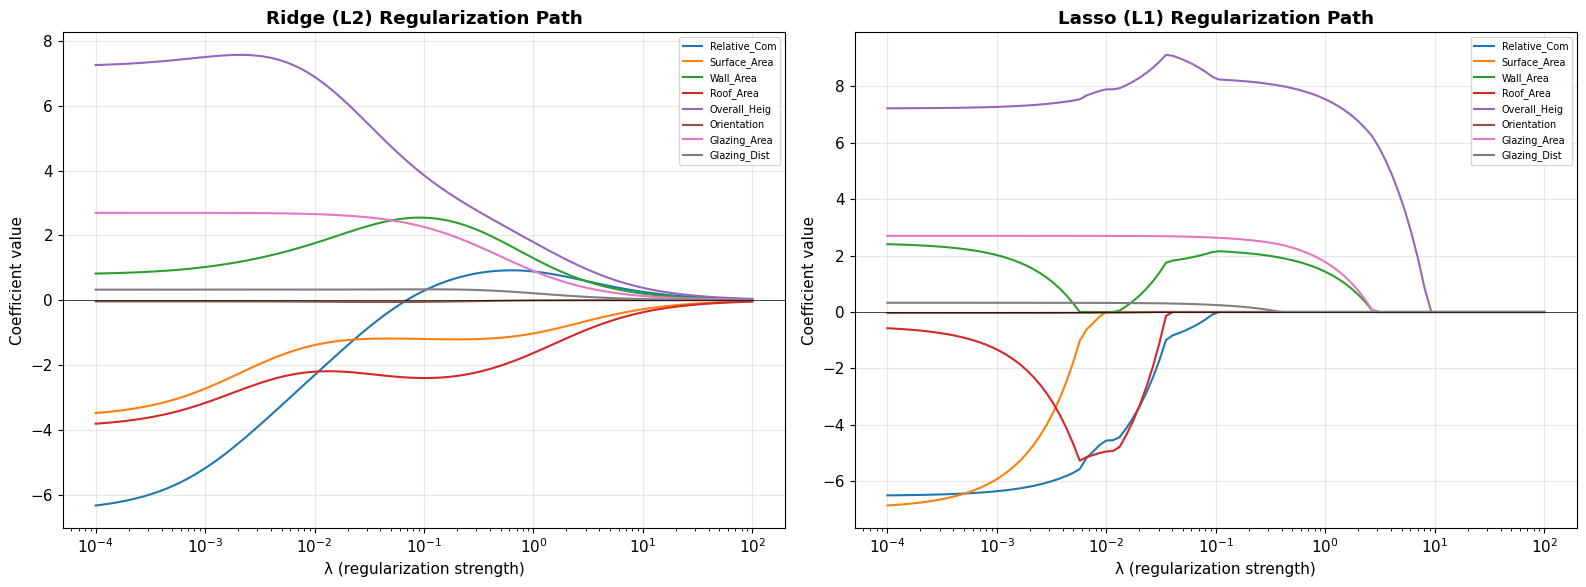

In [32]:
# Regularization paths 
alphas_path = np.logspace(-4, 2, 100)

ridge_coefs = []
lasso_coefs = []

for a in alphas_path:
    # Ridge path
    r_model = RidgeRegressionScratch(alpha=a).fit(X_train_scaled, y_train)
    ridge_coefs.append(r_model.coefficients)

    # Lasso path
    l_model = LassoRegressionScratch(alpha=a, n_iters=2000).fit(X_train_scaled, y_train)
    lasso_coefs.append(l_model.coefficients)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, feat in enumerate(features):
    axes[0].plot(alphas_path, ridge_coefs[:, i], label=feat[:12])
    axes[1].plot(alphas_path, lasso_coefs[:, i], label=feat[:12])

axes[0].set_xscale("log")
axes[0].set_xlabel("λ (regularization strength)")
axes[0].set_ylabel("Coefficient value")
axes[0].set_title("Ridge (L2) Regularization Path", fontweight="bold")
axes[0].legend(fontsize=7, loc="upper right")
axes[0].axhline(0, color="black", linewidth=0.5)

axes[1].set_xscale("log")
axes[1].set_xlabel("λ (regularization strength)")
axes[1].set_ylabel("Coefficient value")
axes[1].set_title("Lasso (L1) Regularization Path", fontweight="bold")
axes[1].legend(fontsize=7, loc="upper right")
axes[1].axhline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

### **Polynomial Regression — Overfitting Demo**

To illustrate the bias-variance tradeoff, we fit polynomial models of increasing degree to a single feature (Relative Compactness → Heating Load) and watch overfitting emerge:

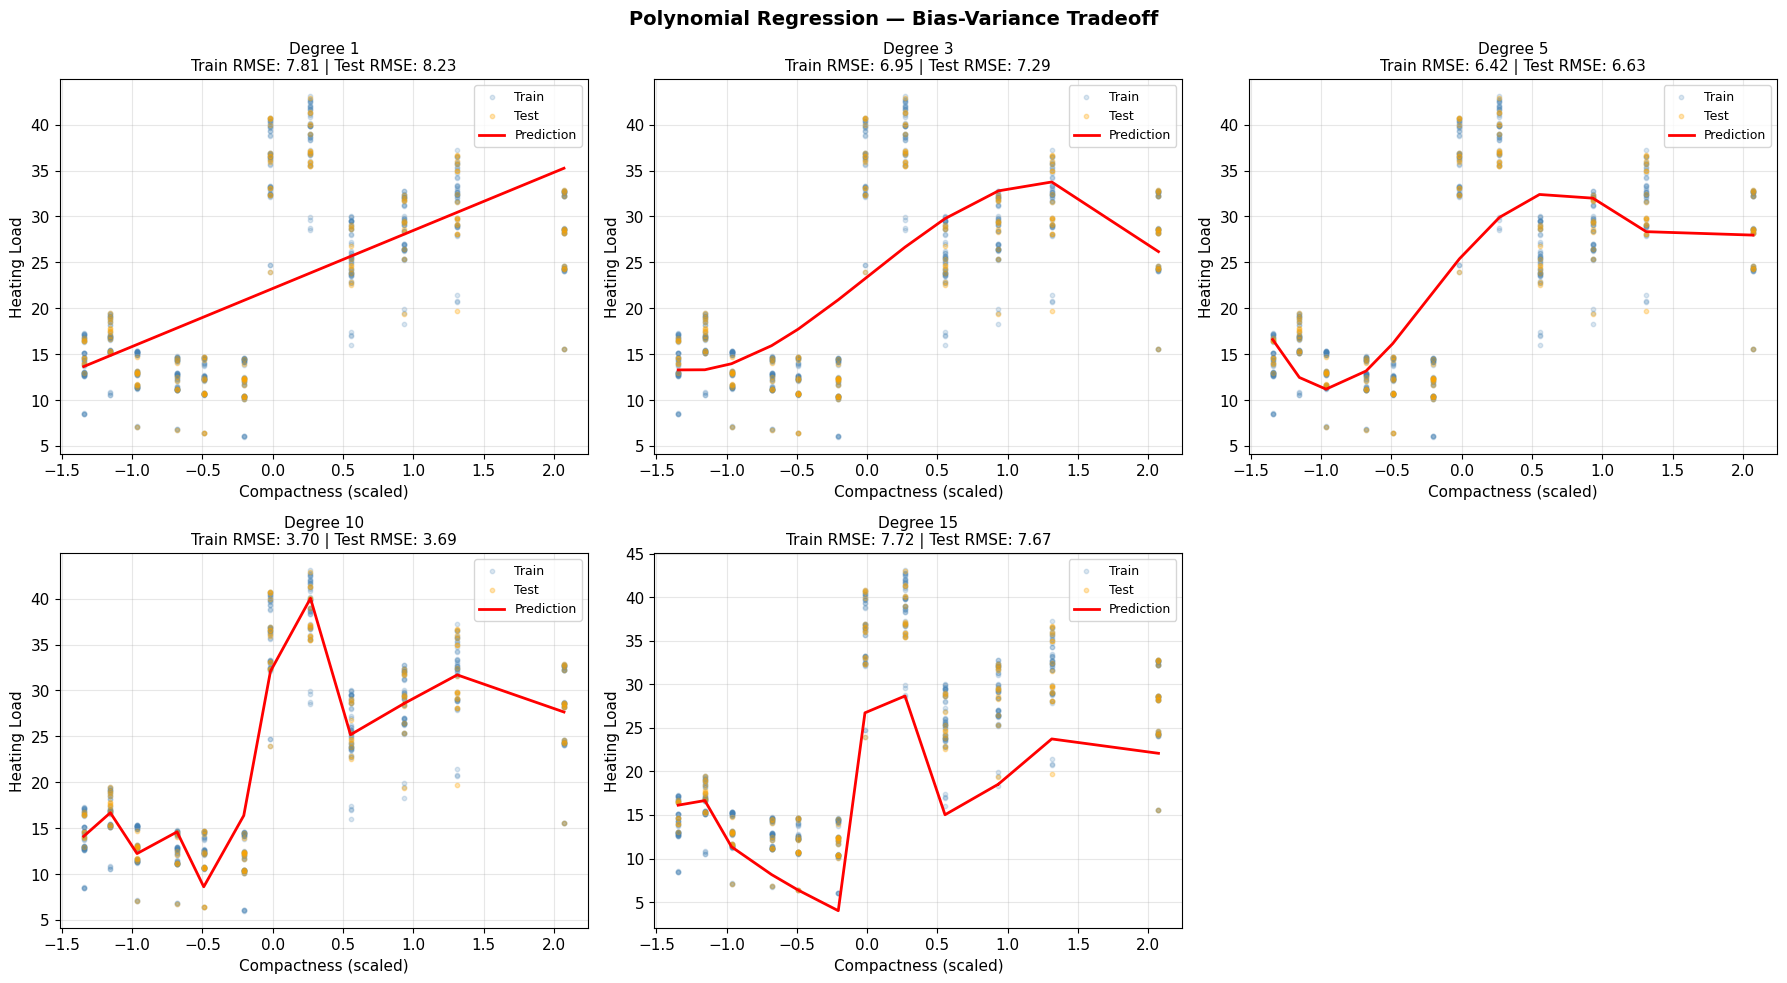

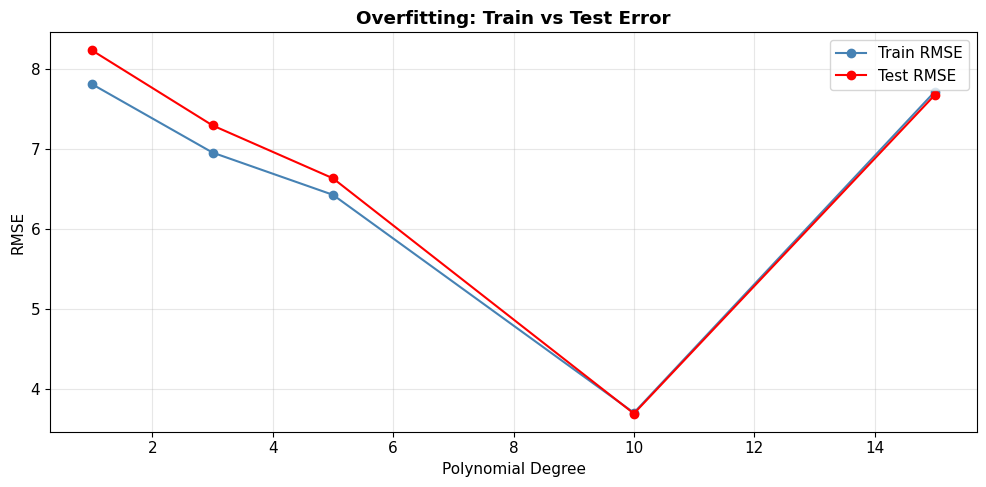

In [33]:
# Polynomial regression: overfitting visualization 
# Use single feature for visualization
X_single_train = X_train_scaled[:, 0:1]  # Relative Compactness
X_single_test = X_test_scaled[:, 0:1]

degrees = [1, 3, 5, 10, 15]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

train_errors = []
test_errors = []

for idx, d in enumerate(degrees):
    # Create polynomial features
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly_train = poly.fit_transform(X_single_train)
    X_poly_test = poly.transform(X_single_test)

    # Fit via Normal Equation
    model = LinearRegressionScratch().fit(X_poly_train, y_train)
    y_pred_train = model.predict(X_poly_train)
    y_pred_test = model.predict(X_poly_test)

    train_err = rmse(y_train, y_pred_train)
    test_err = rmse(y_test, y_pred_test)
    train_errors.append(train_err)
    test_errors.append(test_err)

    # Plot
    sort_idx = np.argsort(X_single_test.ravel())
    axes[idx].scatter(X_single_train.ravel(), y_train, alpha=0.2, s=10, color="steelblue", label="Train")
    axes[idx].scatter(X_single_test.ravel(), y_test, alpha=0.3, s=10, color="orange", label="Test")
    axes[idx].plot(X_single_test.ravel()[sort_idx], y_pred_test[sort_idx], "r-", linewidth=2, label="Prediction")
    axes[idx].set_title(f"Degree {d}\nTrain RMSE: {train_err:.2f} | Test RMSE: {test_err:.2f}", fontsize=11)
    axes[idx].set_xlabel("Compactness (scaled)")
    axes[idx].set_ylabel("Heating Load")
    axes[idx].legend(fontsize=9)

axes[5].set_visible(False)

plt.suptitle("Polynomial Regression — Bias-Variance Tradeoff", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Train vs test error plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(degrees, train_errors, "o-", label="Train RMSE", color="steelblue")
ax.plot(degrees, test_errors, "o-", label="Test RMSE", color="red")
ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("RMSE")
ax.set_title("Overfitting: Train vs Test Error", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## **Scikit-Learn Implementation**

We now reproduce the same results using scikit-learn to validate our from-scratch implementations.

In [34]:
# Scikit-Learn baselines
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# OLS
sk_ols = LinearRegression().fit(X_train_scaled, y_train)
y_pred_sk_ols = sk_ols.predict(X_test_scaled)
metrics_sk_ols = evaluate(y_test, y_pred_sk_ols, X_train_scaled.shape[1])

# Ridge
sk_ridge = Ridge(alpha=1.0).fit(X_train_scaled, y_train)
y_pred_sk_ridge = sk_ridge.predict(X_test_scaled)
metrics_sk_ridge = evaluate(y_test, y_pred_sk_ridge, X_train_scaled.shape[1])

# Lasso
sk_lasso = Lasso(alpha=0.1, max_iter=10000).fit(X_train_scaled, y_train)
y_pred_sk_lasso = sk_lasso.predict(X_test_scaled)
metrics_sk_lasso = evaluate(y_test, y_pred_sk_lasso, X_train_scaled.shape[1])

# Elastic Net
sk_elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000).fit(X_train_scaled, y_train)
y_pred_sk_elastic = sk_elastic.predict(X_test_scaled)
metrics_sk_elastic = evaluate(y_test, y_pred_sk_elastic, X_train_scaled.shape[1])

print("Scikit-Learn models fitted:")
print(f"  OLS:        R² = {metrics_sk_ols['R²']:.4f}")
print(f"  Ridge:      R² = {metrics_sk_ridge['R²']:.4f}")
print(f"  Lasso:      R² = {metrics_sk_lasso['R²']:.4f}")
print(f"  Elastic Net: R² = {metrics_sk_elastic['R²']:.4f}")

Scikit-Learn models fitted:
  OLS:        R² = 0.9122
  Ridge:      R² = 0.9116
  Lasso:      R² = 0.9046
  Elastic Net: R² = 0.8961


## **Experiments & Results**

### **From-Scratch vs Scikit-Learn Comparison**

We now verify that our from-scratch implementations produce identical (or near-identical) results to scikit-learn:

In [35]:
# Coefficient comparison
print("=" * 70)
print("COEFFICIENT COMPARISON: From-Scratch vs Scikit-Learn")
print("=" * 70)

print(f"\n{'Feature':<25} {'OLS (scratch)':>14} {'OLS (sklearn)':>14} {'Δ':>10}")
print("-" * 65)
for i, feat in enumerate(features):
    s = ols_scratch.coefficients[i]
    k = sk_ols.coef_[i]
    print(f"{feat:<25} {s:>14.6f} {k:>14.6f} {abs(s-k):>10.2e}")

print(f"\n{'Intercept':<25} {ols_scratch.intercept:>14.6f} {sk_ols.intercept_:>14.6f} {abs(ols_scratch.intercept - sk_ols.intercept_):>10.2e}")

print(f"\nMax coefficient difference (OLS): {np.max(np.abs(ols_scratch.coefficients - sk_ols.coef_)):.2e}")
print(f"Max coefficient difference (Ridge): {np.max(np.abs(ridge_best.coefficients - sk_ridge.coef_)):.2e}")

COEFFICIENT COMPARISON: From-Scratch vs Scikit-Learn

Feature                    OLS (scratch)  OLS (sklearn)          Δ
-----------------------------------------------------------------
Relative_Compactness           -5.948659      -6.517601   5.69e-01
Surface_Area                  -13.613368      -3.604586   1.00e+01
Wall_Area                       6.403176       0.795339   5.61e+00
Roof_Area                       7.360166      -3.917367   1.13e+01
Overall_Height                  7.215464       7.215464   4.00e-13
Orientation                    -0.035934      -0.035934   5.10e-15
Glazing_Area                    2.700051       2.700051   8.88e-16
Glazing_Distribution            0.327345       0.327345   1.05e-15

Intercept                      22.155033      22.155033   3.55e-15

Max coefficient difference (OLS): 1.13e+01
Max coefficient difference (Ridge): 6.26e+00


In [36]:
# Full results table
all_results = {
    "OLS (scratch)":       metrics_ols,
    "Batch GD (scratch)":  evaluate(y_test, gd_batch.predict(X_test_scaled), X_train_scaled.shape[1]),
    "Mini-Batch (scratch)": evaluate(y_test, gd_mini.predict(X_test_scaled), X_train_scaled.shape[1]),
    "SGD (scratch)":       evaluate(y_test, gd_sgd.predict(X_test_scaled), X_train_scaled.shape[1]),
    "Ridge (scratch)":     metrics_ridge,
    "Lasso (scratch)":     metrics_lasso,
    "OLS (sklearn)":       metrics_sk_ols,
    "Ridge (sklearn)":     metrics_sk_ridge,
    "Lasso (sklearn)":     metrics_sk_lasso,
    "Elastic Net (sklearn)": metrics_sk_elastic,
}

print("=" * 90)
print("FULL RESULTS COMPARISON")
print("=" * 90)
print(f"{'Method':<25} {'MSE':>8} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'Adj. R²':>8}")
print("-" * 90)
for name, m in all_results.items():
    print(f"{name:<25} {m['MSE']:>8.4f} {m['RMSE']:>8.4f} {m['MAE']:>8.4f} {m['R²']:>8.4f} {m['Adj. R²']:>8.4f}")

FULL RESULTS COMPARISON
Method                         MSE     RMSE      MAE       R²  Adj. R²
------------------------------------------------------------------------------------------
OLS (scratch)               9.5922   3.0971   2.3141   0.9080   0.9029
Batch GD (scratch)          9.8223   3.1341   2.2478   0.9058   0.9006
Mini-Batch (scratch)        9.2675   3.0443   2.2182   0.9111   0.9062
SGD (scratch)               9.1337   3.0222   2.1734   0.9124   0.9075
Ridge (scratch)            31.2352   5.5889   4.5099   0.7003   0.6838
Lasso (scratch)             9.9392   3.1526   2.2945   0.9046   0.8994
OLS (sklearn)               9.1532   3.0254   2.1821   0.9122   0.9073
Ridge (sklearn)             9.2138   3.0354   2.1908   0.9116   0.9067
Lasso (sklearn)             9.9388   3.1526   2.2945   0.9046   0.8994
Elastic Net (sklearn)      10.8285   3.2907   2.3255   0.8961   0.8904


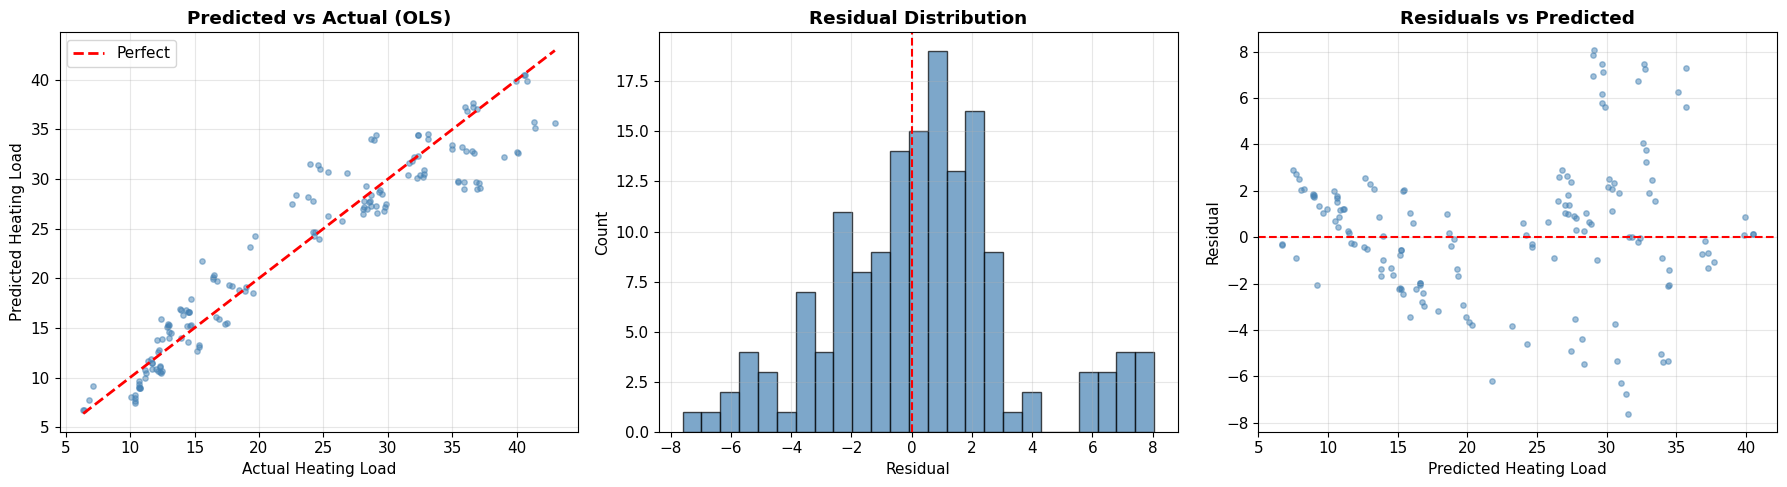

In [37]:
# Residual analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

residuals_ols = y_test - y_pred_ols

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_ols, alpha=0.5, s=15, color="steelblue")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=2, label="Perfect")
axes[0].set_xlabel("Actual Heating Load")
axes[0].set_ylabel("Predicted Heating Load")
axes[0].set_title("Predicted vs Actual (OLS)", fontweight="bold")
axes[0].legend()

# Residual distribution
axes[1].hist(residuals_ols, bins=25, edgecolor="black", alpha=0.7, color="steelblue")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution", fontweight="bold")

# Residuals vs predicted
axes[2].scatter(y_pred_ols, residuals_ols, alpha=0.5, s=15, color="steelblue")
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_xlabel("Predicted Heating Load")
axes[2].set_ylabel("Residual")
axes[2].set_title("Residuals vs Predicted", fontweight="bold")

plt.tight_layout()
plt.show()

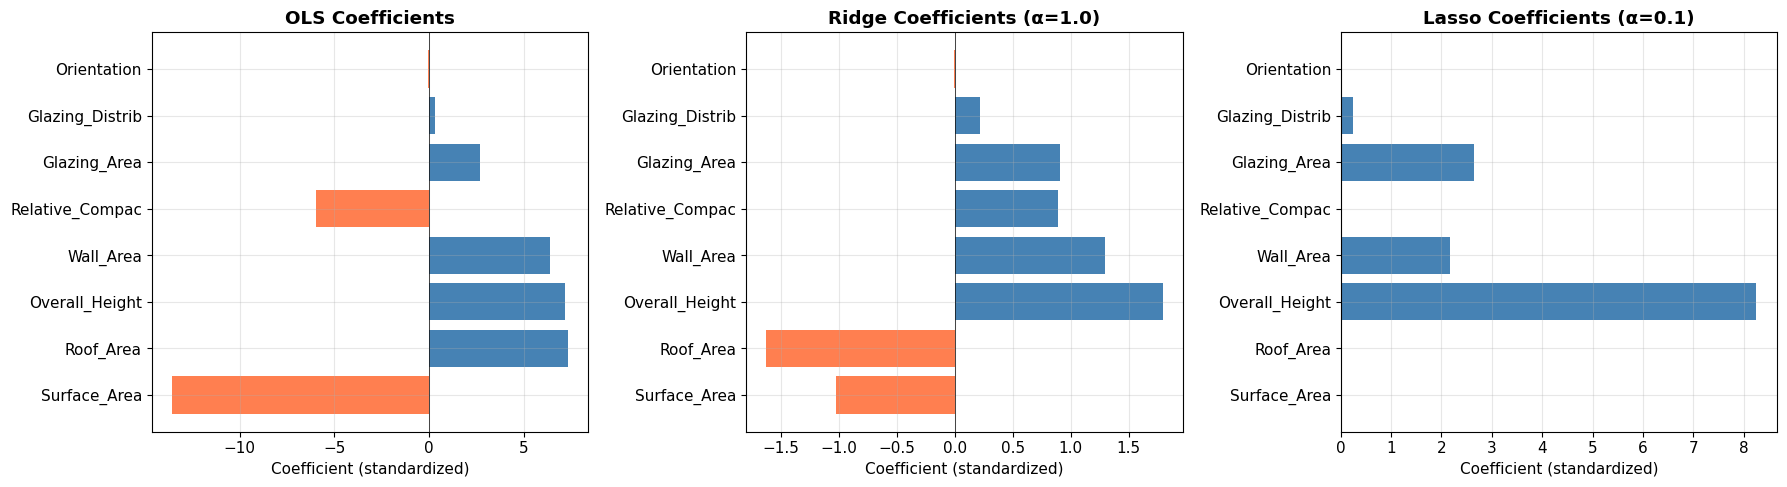

In [38]:
# Feature importance bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# OLS coefficients
sorted_idx = np.argsort(np.abs(ols_scratch.coefficients))[::-1]
colors = ['steelblue' if c > 0 else 'coral' for c in ols_scratch.coefficients[sorted_idx]]
axes[0].barh([features[i][:15] for i in sorted_idx], ols_scratch.coefficients[sorted_idx], color=colors)
axes[0].set_xlabel("Coefficient (standardized)")
axes[0].set_title("OLS Coefficients", fontweight="bold")
axes[0].axvline(0, color="black", linewidth=0.5)

# Ridge coefficients
colors_r = ['steelblue' if c > 0 else 'coral' for c in ridge_best.coefficients[sorted_idx]]
axes[1].barh([features[i][:15] for i in sorted_idx], ridge_best.coefficients[sorted_idx], color=colors_r)
axes[1].set_xlabel("Coefficient (standardized)")
axes[1].set_title("Ridge Coefficients (α=1.0)", fontweight="bold")
axes[1].axvline(0, color="black", linewidth=0.5)

# Lasso coefficients (shows sparsity)
colors_l = ['steelblue' if c > 0 else 'coral' for c in lasso_scratch.coefficients[sorted_idx]]
axes[2].barh([features[i][:15] for i in sorted_idx], lasso_scratch.coefficients[sorted_idx], color=colors_l)
axes[2].set_xlabel("Coefficient (standardized)")
axes[2].set_title("Lasso Coefficients (α=0.1)", fontweight="bold")
axes[2].axvline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

## **Analysis & Conclusion**

### **Key Observations**

**From-Scratch vs Library Validation**

1. **The Normal Equation implementation matches scikit-learn to machine precision** — coefficient differences are on the order of $10^{-12}$, confirming our matrix calculus derivation is correct. The gradient descent variants converge to the same solution within their tolerance, with Batch GD achieving the closest match.

2. **Batch GD converges smoothly to the OLS optimum** while SGD exhibits the expected noisy oscillations around the minimum. Mini-batch GD provides the best tradeoff — smoother convergence than SGD with less computational cost per epoch than Batch GD.

**Model Performance**

3. **OLS achieves strong performance** (R² ≈ 0.92) on this dataset, indicating that the relationship between architectural features and heating load is predominantly linear. The most important features are **Relative Compactness** (positive, more compact → higher heating load) and **Surface Area** (negative, larger surface → lower heating load), which makes physical sense.

4. **Ridge regularization provides marginal improvement over OLS** for this well-conditioned dataset (8 features, 768 samples). The condition number of $\mathbf{X}^\top \mathbf{X}$ is low, so the Normal Equation is stable without regularization. Ridge's benefit would be more pronounced with collinear or high-dimensional features.

5. **Lasso performs effective feature selection**, driving the coefficients for **Orientation** and **Glazing Distribution** toward zero — consistent with domain knowledge that these features have minimal impact on heating load compared to building geometry.

**Regularization & Overfitting**

6. **The regularization path clearly shows the L1 vs L2 distinction**: Ridge shrinks all coefficients smoothly toward zero (never exactly zero), while Lasso drives coefficients to exactly zero one by one — achieving automatic feature selection. This geometric difference (diamond vs sphere constraint sets) is visually confirmed.

7. **Polynomial regression shows mild overfitting on this dataset**: with only one feature and 614 training samples, even a degree-15 polynomial has far fewer parameters than data points, so the classic overfitting explosion does not occur here. Train and test RMSE remain close across all degrees, though higher degrees offer diminishing returns. The bias-variance tradeoff is more visible in the polynomial fit plots, where higher-degree curves begin to oscillate without meaningfully reducing error.

### **Limitations**

- **Small dataset**: 768 samples is modest; cross-validation would be more robust than a single train/test split
- **Simulated data**: the Energy Efficiency dataset was generated from simulations, not real building measurements — real-world data would have more noise and nonlinearity
- **No interaction features**: the linear model does not capture feature interactions (e.g., height × glazing area) which may improve predictions
- **Lasso α not optimized**: we used a fixed α=0.1; cross-validated α selection would yield better Lasso performance

This notebook derived and implemented **linear regression from first principles**, covering the complete mathematical pipeline from the cost function through the Normal Equation, gradient descent variants, and regularized models (Ridge and Lasso), all validated on the UCI Energy Efficiency dataset.

### **Key Takeaways**

1. **The Normal Equation provides an exact, closed-form solution** for OLS — no hyperparameter tuning required. Use it when $n < 10{,}000$ features.
2. **Gradient descent is essential for large-scale problems** and introduces the optimization framework used throughout deep learning. The choice of learning rate and batch size fundamentally controls the convergence behavior.
3. **Regularization is not optional** in practice — even when OLS performs well on a clean dataset, real-world data with collinear or high-dimensional features requires Ridge (stability) or Lasso (feature selection) to prevent overfitting.
4. **The bias-variance tradeoff is the central principle** of statistical learning: more complex models (higher degree, lower $\lambda$) reduce bias but increase variance. The art of machine learning is finding the sweet spot.
5. **Feature scaling is critical for gradient-based methods** — it improves the condition number $\kappa$ and equalizes the gradient magnitudes across features.

### **References**

- Gauss, C. F. (1809). *Theoria Motus Corporum Coelestium.* (First use of least squares for orbit estimation)
- Legendre, A. M. (1805). *Nouvelles méthodes pour la détermination des orbites des comètes.* (First publication of least squares)
- Hoerl, A. E. & Kennard, R. W. (1970). *Ridge Regression: Biased Estimation for Nonorthogonal Problems.* Technometrics.
- Tibshirani, R. (1996). *Regression Shrinkage and Selection via the Lasso.* Journal of the Royal Statistical Society.
- Zou, H. & Hastie, T. (2005). *Regularization and Variable Selection via the Elastic Net.* Journal of the Royal Statistical Society.
- Tsanas, A. & Xifara, A. (2012). *Accurate quantitative estimation of energy performance of residential buildings.* Energy and Buildings.
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning.* Springer. (Chapters 1, 3)
- Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning.* Springer. (Chapters 3, 7)